In [1]:
import os
import pandas as pd
import seaborn as sns

In [2]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/metrics_new_donor_different_k"
    

In [3]:
files = os.listdir(file_dir)

In [4]:
len(files)

0

In [105]:
dfs = []
for file in files:
    dfs.append(pd.read_csv(os.path.join(file_dir, file)))

In [106]:
df = pd.concat(dfs, axis=0)

In [107]:
df.head()

,Unnamed: 0,20,50,100,200,500,1000,cond,wandb_name,cytokine_in_train
0,deg_decoded_r_squared_CD4 Naive,0.961267,0.980954,0.968406,0.973019,0.974654,0.976367,Donor6_BAFF,absurd-puddle-164,65
1,deg_decoded_r_squared_NKT,0.834091,0.769268,0.832238,0.870198,0.906053,0.918889,Donor6_BAFF,absurd-puddle-164,65
2,deg_decoded_r_squared_CD56-dim NK,0.853904,0.913705,0.941078,0.953411,0.966458,0.970541,Donor6_BAFF,absurd-puddle-164,65
3,deg_decoded_r_squared_CD4 Memory,0.917701,0.946183,0.970098,0.974248,0.977575,0.978223,Donor6_BAFF,absurd-puddle-164,65
4,deg_decoded_r_squared_MAIT,0.899330,0.914033,0.929243,0.942599,0.948854,0.949845,Donor6_BAFF,absurd-puddle-164,65


In [127]:
df.drop_duplicates("200").shape

(2377, 12)

In [128]:
df.shape

(2382, 12)

In [110]:
df["cond"].value_counts()

cond
Donor6_BAFF           84
Donor6_M-CSF          84
Donor2_M-CSF          84
Donor6_FasL           84
Donor2_IL-1Ra         84
Donor2_FasL           84
Donor6_IL-1Ra         84
Donor6_ADSF           84
Donor6_OX40L          84
Donor6_IFN-gamma      84
Donor2_CD27L          84
Donor2_ADSF           84
Donor2_IFN-gamma      84
Donor2_OX40L          84
Donor6_CD27L          84
Donor10_IFN-omega     78
Donor10_OX40L         78
Donor6_IFN-omega      78
Donor10_IL-1Ra        78
Donor10_FasL          78
Donor10_CD27L         78
Donor10_ADSF          78
Donor2_IFN-omega      78
Donor6_IL-32-beta     78
Donor2_IL-32-beta     78
Donor10_M-CSF         72
Donor10_IFN-gamma     72
Donor2_BAFF           66
Donor10_IL-32-beta    66
Donor10_BAFF          66
Name: count, dtype: int64

In [108]:
df["donor"] = df.apply(lambda x: x["cond"].split("_")[0], axis=1)
df["cytokine"] = df.apply(lambda x: "_".join(x["cond"].split("_")[1:]), axis=1)

In [109]:
df["donor"].value_counts()

donor
Donor6     828
Donor2     810
Donor10    744
Name: count, dtype: int64

In [26]:
df["cytokine"].value_counts()

cytokine
IL-1Ra        246
FasL          246
OX40L         246
CD27L         246
ADSF          246
IFN-gamma     240
M-CSF         240
IFN-omega     234
IL-32-beta    222
BAFF          216
Name: count, dtype: int64

<Axes: >

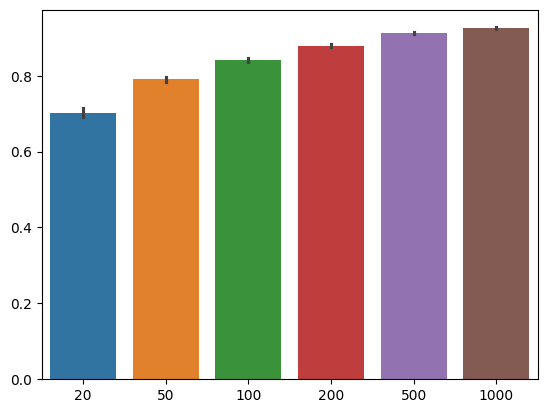

In [17]:
sns.barplot(df[["20", "50", "100", "200", "500", "1000"]])

# Mean model 1

In [5]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/additive_model/pbmc_new_donor/mean_model_1_different_k"
    

In [6]:
files = os.listdir(file_dir)
len(files)

360

In [7]:
dfs = []
for file in files:
    df_tmp = pd.read_csv(os.path.join(file_dir, file))
    df_tmp2 = pd.DataFrame(df_tmp[["20", "50", "100", "200", "500", "1000"]].mean()).T
    df_tmp2["condition"] = df_tmp.iloc[0]["condition"]
    dfs.append(df_tmp2)

In [8]:
df_mean1 = pd.concat(dfs, axis=0)

In [9]:
df_mean1.head()

,20,50,100,200,500,1000,condition
0,0.610018,0.790229,0.849619,0.895477,0.930530,0.942960,Donor11_FasL_65
0,0.535375,0.749657,0.839986,0.905067,0.944255,0.955597,Donor4_IFN-gamma_65
0,0.456849,0.544896,0.669888,0.760478,0.828095,0.857625,Donor3_IL-1Ra_65
0,0.830700,0.900942,0.936021,0.954480,0.966174,0.970261,Donor3_FasL_65
0,0.758139,0.863416,0.918703,0.944361,0.962037,0.968696,Donor4_CD27L_65


In [10]:
df_mean1["donor"] = df_mean1.apply(lambda x: x["condition"].split("_")[0], axis=1)
df_mean1["cytokine"] = df_mean1.apply(lambda x: "_".join(x["condition"].split("_")[1:]), axis=1)

In [11]:
df_mean1["donor"].value_counts()

donor
Donor11    30
Donor4     30
Donor3     30
Donor1     30
Donor7     30
Donor10    30
Donor9     30
Donor5     30
Donor6     30
Donor2     30
Donor8     30
Donor12    30
Name: count, dtype: int64

In [12]:
df_mean1["cytokine"].value_counts()

cytokine
FasL_65          36
IFN-gamma_65     36
IL-1Ra_65        36
CD27L_65         36
ADSF_65          36
IFN-omega_65     36
BAFF_65          36
M-CSF_65         36
OX40L_65         36
IL-32-beta_65    36
Name: count, dtype: int64

<Axes: >

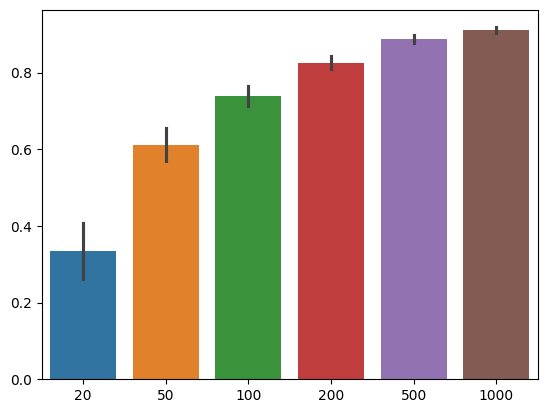

In [13]:
sns.barplot(df_mean1[["20", "50", "100", "200", "500", "1000"]])

# Mean model 2

In [14]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/additive_model/pbmc_new_donor/mean_model_2_different_k"
    

In [15]:
files = os.listdir(file_dir)
len(files)

360

In [16]:
dfs = []
for file in files:
    df_tmp = pd.read_csv(os.path.join(file_dir, file))
    df_tmp2 = pd.DataFrame(df_tmp[["20", "50", "100", "200", "500", "1000"]].mean()).T
    df_tmp2["condition"] = df_tmp.iloc[0]["condition"]
    dfs.append(df_tmp2)

In [17]:
df_mean2 = pd.concat(dfs, axis=0)

In [18]:
df_mean2.head()

,20,50,100,200,500,1000,condition
0,0.470093,0.578571,0.682099,0.771251,0.836082,0.856437,Donor8_IL-32-beta_65
0,0.530948,0.694500,0.730959,0.757560,0.780239,0.792004,Donor7_OX40L_65
0,0.555312,0.708694,0.752593,0.793198,0.818736,0.824271,Donor7_ADSF_65
0,-1.449164,-0.992447,-0.411763,-0.001330,0.179469,0.129069,Donor4_IL-1Ra_65
0,0.290827,0.489891,0.601089,0.711559,0.798903,0.818739,Donor12_IFN-omega_65


In [19]:
df_mean2["donor"] = df_mean2.apply(lambda x: x["condition"].split("_")[0], axis=1)
df_mean2["cytokine"] = df_mean2.apply(lambda x: "_".join(x["condition"].split("_")[1:]), axis=1)

In [20]:
df_mean2["donor"].value_counts()

donor
Donor8     30
Donor7     30
Donor4     30
Donor12    30
Donor9     30
Donor3     30
Donor5     30
Donor6     30
Donor2     30
Donor10    30
Donor11    30
Donor1     30
Name: count, dtype: int64

In [21]:
df_mean2["cytokine"].value_counts()

cytokine
IL-32-beta_65    36
OX40L_65         36
ADSF_65          36
IL-1Ra_65        36
IFN-omega_65     36
FasL_65          36
BAFF_65          36
IFN-gamma_65     36
M-CSF_65         36
CD27L_65         36
Name: count, dtype: int64

<Axes: >

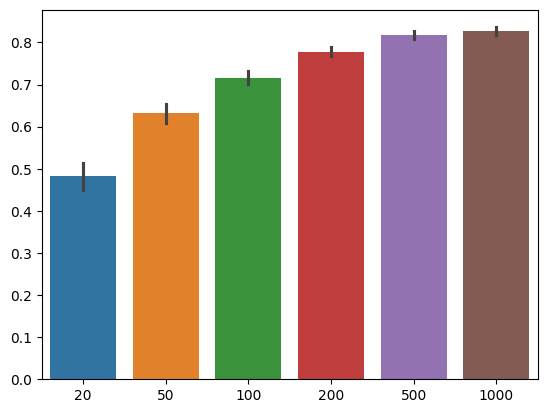

In [22]:
sns.barplot(df_mean2[["20", "50", "100", "200", "500", "1000"]])

In [23]:
df1 = df_mean1.set_index("condition")
df2 = df_mean2.set_index("condition")

In [24]:
df1["model"] = "mean1"
df2["model"] = "mean2"

In [25]:
df = pd.concat((df1, df2))

In [26]:
df_long = df[["20", "50", "100", "200", "500", "1000", "model"]].melt(id_vars="model", var_name="top_k", value_name="r_sq")



In [27]:
df_long

,model,top_k,r_sq
0,mean1,20,0.610018
1,mean1,20,0.535375
2,mean1,20,0.456849
3,mean1,20,0.830700
4,mean1,20,0.758139
...,...,...,...
4315,mean2,1000,0.777371
4316,mean2,1000,0.852866
4317,mean2,1000,0.843137
4318,mean2,1000,0.844880


<Axes: xlabel='top_k', ylabel='r_sq'>

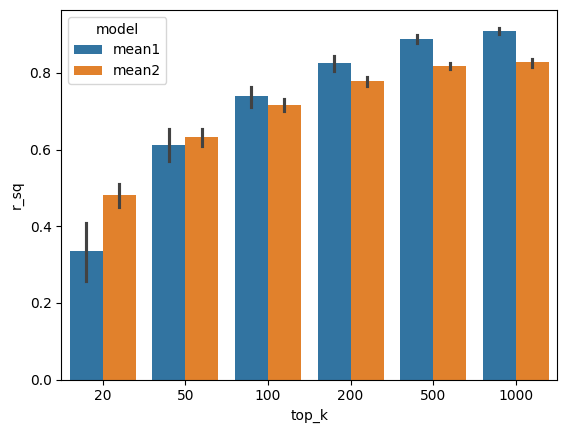

In [28]:
sns.barplot(data=df_long, x="top_k", y="r_sq", hue="model")

In [29]:
df_mean1["donor"].value_counts()

donor
Donor11    30
Donor4     30
Donor3     30
Donor1     30
Donor7     30
Donor10    30
Donor9     30
Donor5     30
Donor6     30
Donor2     30
Donor8     30
Donor12    30
Name: count, dtype: int64

In [30]:
df_mean1["cytokine"].value_counts()

cytokine
FasL_65          36
IFN-gamma_65     36
IL-1Ra_65        36
CD27L_65         36
ADSF_65          36
IFN-omega_65     36
BAFF_65          36
M-CSF_65         36
OX40L_65         36
IL-32-beta_65    36
Name: count, dtype: int64

In [31]:
df_mean1["condition2"] = df_mean1.apply(lambda x: x["donor"] + "_" + x["cytokine"], axis=1)

In [32]:
df_mean1["condition2"].value_counts()

condition2
Donor10_OX40L_65        3
Donor4_FasL_65          3
Donor5_IL-1Ra_65        3
Donor1_BAFF_65          3
Donor3_IL-32-beta_65    3
                       ..
Donor3_FasL_65          3
Donor4_CD27L_65         3
Donor1_IL-1Ra_65        3
Donor1_ADSF_65          3
Donor7_IFN-omega_65     3
Name: count, Length: 120, dtype: int64

# Identity

In [33]:
file_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/additive_model/pbmc_new_donor/identity_different_k"
    

In [34]:
files = os.listdir(file_dir)
len(files)

360

In [35]:
dfs = []
for file in files:
    df_tmp = pd.read_csv(os.path.join(file_dir, file))
    df_tmp2 = pd.DataFrame(df_tmp[["20", "50", "100", "200", "500", "1000"]].mean()).T
    df_tmp2["condition"] = df_tmp.iloc[0]["condition"]
    dfs.append(df_tmp2)

In [36]:
df_id = pd.concat(dfs, axis=0)

In [37]:
df_id["donor"] = df_id.apply(lambda x: x["condition"].split("_")[0], axis=1)
df_id["cytokine"] = df_id.apply(lambda x: "_".join(x["condition"].split("_")[1:]), axis=1)

In [40]:
df_id["donor"].value_counts()

donor
Donor10    30
Donor2     30
Donor1     30
Donor7     30
Donor9     30
Donor8     30
Donor4     30
Donor11    30
Donor3     30
Donor5     30
Donor12    30
Donor6     30
Name: count, dtype: int64

In [41]:
df_id["cytokine"].value_counts()

cytokine
OX40L_65         36
ADSF_65          36
FasL_65          36
IL-1Ra_65        36
IFN-omega_65     36
BAFF_65          36
IL-32-beta_65    36
M-CSF_65         36
CD27L_65         36
IFN-gamma_65     36
Name: count, dtype: int64

# Closest embedding